# Sales Forecasting with Ensemble Models
## Multi-series monthly projection using Gradient Boosting, Random Forest and Prophet

This notebook implements a complete sales forecasting pipeline for a portfolio of anonymized product-market combinations, covering data ingestion through 12-month forward projections.

**Methodology overview:**
- **Data:** Monthly sales volume across ~12 product-market series (2021–2024)
- **Validation:** Temporal train/test split with TimeSeriesSplit cross-validation (4 folds)
- **Models:** Gradient Boosting and Random Forest (hyperparameter-tuned via Optuna) combined with Prophet (one model per series)
- **Ensemble:** Scipy-optimized weighted combination to minimize SMAPE on the hold-out period
- **Output:** 12-month projections (Jan–Dec 2025) exported to a formatted Excel workbook

> **Note:** All product and market identifiers have been anonymized. The dataset and file paths reflect a Google Colab + Google Drive setup

---

## 1. Library Imports and Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
!pip install lightgbm optuna prophet -q

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/0. Dev/1. Modelo de Projeção/b_anom_5y_dez24.xlsx'
df = pd.read_excel(path)

Mounted at /content/drive


In [3]:
!pip install openpyxl -q
df.to_csv('/content/drive/MyDrive/0. Dev/1. Modelo de Projeção/base_tratada.csv', index=False, sep=';')

In [4]:
path = '/content/drive/MyDrive/0. Dev/1. Modelo de Projeção/base_tratada.csv'
df = pd.read_csv(path, sep=';')

---
## 2. Data Quality Checks and Preparation

Before building any model, it is important to understand the structure and quality of the data. This section covers:
- Schema inspection (shape, column names, data types)
- Null value assessment
- Date parsing and consistency validation
- Aggregation by product-market pair at monthly granularity
- Full date-range grid construction to ensure no months are missing per series

In [5]:
df.shape

(4340, 11)

In [6]:
df.columns.tolist()

['Periodo',
 'Year',
 'Canal',
 'Data',
 'MAT_M',
 'QRT_M',
 'Fator_M',
 'Unidades',
 'Merc_anom',
 'Prod_anom',
 'sku_anom']

In [7]:
df.dtypes

,0
Periodo,int64
Year,int64
Canal,object
Data,object
MAT_M,object
QRT_M,object
Fator_M,float64
Unidades,float64
Merc_anom,object
Prod_anom,object


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Periodo,0
Year,0
Canal,0
Data,0
MAT_M,0
QRT_M,0
Fator_M,0
Unidades,0
Merc_anom,0
Prod_anom,0


In [9]:
df.head()

,Periodo,Year,Canal,Data,MAT_M,QRT_M,Fator_M,Unidades,Merc_anom,Prod_anom,sku_anom
0,20200100,2020,Clinicas,2020-01-01,--,20.21/Q3,1.0,1974.0,M3,M3_P1,M3_P1_S3
1,20200100,2020,Hospital Privado,2020-01-01,--,20.21/Q3,1.0,10.0,M3,M3_P1,M3_P1_S3
2,20200100,2020,Hospital Publico,2020-01-01,--,20.21/Q3,1.0,6.0,M3,M3_P1,M3_P1_S3
3,20200100,2020,Outros,2020-01-01,--,20.21/Q3,1.0,5.0,M3,M3_P1,M3_P1_S3
4,20200100,2020,Clinicas,2020-01-01,--,20.21/Q3,1.0,1508.0,M3,M3_P1,M3_P1_S4


In [10]:
df['Data'] = pd.to_datetime(df['Data'])
print("Datas únicas (dia):", df['Data'].dt.day.unique())
print("Nulos em Data:", df['Data'].isnull().sum())

Datas únicas (dia): [1]
Nulos em Data: 0


In [11]:
df_model = (
    df
    .groupby(['Prod_anom', 'Merc_anom', 'Data'], as_index=False)
    .agg({'Unidades': 'sum'})
    .sort_values(['Prod_anom', 'Merc_anom', 'Data'])
)

# Preencher meses faltantes
all_dates = pd.date_range(start=df_model['Data'].min(), end=df_model['Data'].max(), freq='MS')
comb      = df_model[['Prod_anom', 'Merc_anom']].drop_duplicates()
full_grid = (
    comb.assign(key=1)
    .merge(pd.DataFrame({'Data': all_dates, 'key': 1}), on='key')
    .drop('key', axis=1)
)
df_model = full_grid.merge(df_model, on=['Prod_anom', 'Merc_anom', 'Data'], how='left')
df_model['Unidades'] = df_model['Unidades'].fillna(0)

print("Shape:", df_model.shape)
print("Séries únicas:", df_model[['Prod_anom','Merc_anom']].drop_duplicates().shape[0])

Shape: (720, 4)
Séries únicas: 12


---
## 3. Feature Engineering

The following features are constructed to give the models both temporal context and cross-series information:

| Feature group | Features |
|---|---|
| **Lagged values** | `lag_1`, `lag_3`, `lag_6`, `lag_12` |
| **Rolling averages** | `rolling_mean_3`, `rolling_mean_6`, `rolling_mean_12` |
| **Calendar** | `mes` (month), `ano` (year) |
| **Trend** | Cumulative count per series |
| **Target encoding** | Mean sales per product (`prod_enc`) and per market (`merc_enc`) — computed exclusively on training data to prevent leakage |

All rolling and lag features use a one-period shift before the window calculation, ensuring no information from the current observation leaks into its own features.

In [12]:
df_model = df_model.sort_values(['Prod_anom', 'Merc_anom', 'Data']).reset_index(drop=True)

# Lags
for lag in [1, 3, 6, 12]:
    df_model[f'lag_{lag}'] = (
        df_model.groupby(['Prod_anom', 'Merc_anom'])['Unidades'].shift(lag)
    )

# Médias móveis
for w in [3, 6, 12]:
    df_model[f'rolling_mean_{w}'] = (
        df_model.groupby(['Prod_anom', 'Merc_anom'])['Unidades']
        .transform(lambda x: x.shift(1).rolling(w).mean())
    )

# Calendário e tendência
df_model['mes']   = df_model['Data'].dt.month
df_model['ano']   = df_model['Data'].dt.year
df_model['trend'] = df_model.groupby(['Prod_anom', 'Merc_anom']).cumcount()

print("Features temporais criadas.")

Features temporais criadas.


In [13]:
# Target encoding — calculado APENAS no treino para evitar leakage
split_date  = '2024-01-01'
global_mean = df_model[df_model['Data'] < split_date]['Unidades'].mean()

prod_mean = (df_model[df_model['Data'] < split_date]
             .groupby('Prod_anom')['Unidades'].mean().rename('prod_enc'))
merc_mean = (df_model[df_model['Data'] < split_date]
             .groupby('Merc_anom')['Unidades'].mean().rename('merc_enc'))

df_model = df_model.merge(prod_mean, on='Prod_anom', how='left')
df_model = df_model.merge(merc_mean, on='Merc_anom', how='left')
df_model['prod_enc'] = df_model['prod_enc'].fillna(global_mean)
df_model['merc_enc'] = df_model['merc_enc'].fillna(global_mean)

df_model = df_model.dropna()
print("Shape após dropna:", df_model.shape)

Shape após dropna: (576, 16)


---
## 4. Temporal Train/Test Split and Metrics

The dataset is split along the time axis:
- **Training set:** all months before January 2024
- **Test set:** January–December 2024

This strict temporal split ensures the model is always evaluated on data it has never seen. No random shuffling is applied.

**Evaluation metrics:**
- **SMAPE** (Symmetric Mean Absolute Percentage Error) — primary metric, robust to near-zero values
- **MAPE** — reported for reference, computed only on non-zero actuals
- **MAE / RMSE** — absolute error metrics for business-level interpretation
- **R²** — explained variance

In [14]:
split_date = '2024-01-01'

df_train = df_model[df_model['Data'] < split_date]
df_test  = df_model[df_model['Data'] >= split_date]

print(f"Treino: {df_train.shape[0]} linhas  ({df_train['Data'].min().date()} → {df_train['Data'].max().date()})")
print(f"Teste:  {df_test.shape[0]} linhas   ({df_test['Data'].min().date()} → {df_test['Data'].max().date()})")

Treino: 432 linhas  (2021-01-01 → 2023-12-01)
Teste:  144 linhas   (2024-01-01 → 2024-12-01)


In [15]:
features = [
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
    'mes', 'ano', 'trend',
    'prod_enc', 'merc_enc'
]
target = 'Unidades'

X_train = df_train[features];  y_train = df_train[target]
X_test  = df_test[features];   y_test  = df_test[target]

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask  = denom > 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def mape_seguro(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def avaliar(y_true, y_pred, nome=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s    = smape(y_true, y_pred)
    m    = mape_seguro(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if nome:
        print(f"── {nome} ──")
    print(f"  SMAPE: {s:.2f}%   MAE: {mae:,.0f}   RMSE: {rmse:,.0f}   MAPE: {m:.2f}%   R²: {r2:.3f}")
    return {'Modelo': nome, 'SMAPE': s, 'MAPE': m, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

resultados = []

---
## 5. Baseline Model

Before training any ML model, a naive baseline is established: the prediction for each month is simply the value observed one month prior (`lag_1`). This serves as the minimum performance threshold that any model must exceed to justify its complexity.

In [17]:
y_pred_baseline = X_test['lag_1']
res = avaliar(y_test, y_pred_baseline, 'Baseline (lag_1)')
resultados.append(res)

── Baseline (lag_1) ──
  SMAPE: 32.37%   MAE: 13,785   RMSE: 21,642   MAPE: 43.30%   R²: 0.755


---
## 6. Temporal Cross-Validation

`TimeSeriesSplit` with 4 folds is used to compare model families before hyperparameter tuning. Because data is ordered in time, each fold's validation set always comes after its training set — standard k-fold would introduce future data leakage here.

The four models evaluated are:
- **Random Forest** — bagging ensemble, robust to outliers
- **Gradient Boosting** — sequential boosting, strong on tabular data
- **XGBoost** — gradient boosting with regularization (reference)
- **LightGBM** — gradient boosting optimized for speed (reference)

In [18]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

tscv = TimeSeriesSplit(n_splits=4)

def cv_smape(model, X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = m.predict(X.iloc[val_idx])
        scores.append(smape(y.iloc[val_idx], pred))
    return np.array(scores)

modelos_cv = {
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'LightGBM':          LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1),
}

print("Validação cruzada temporal (4 folds):\n")
for nome, modelo in modelos_cv.items():
    scores = cv_smape(modelo, X_train, y_train, tscv)
    print(f"  {nome:25s}  SMAPE médio: {scores.mean():.2f}%  ±{scores.std():.2f}%")

Validação cruzada temporal (4 folds):

  Random Forest              SMAPE médio: 43.59%  ±14.31%
  Gradient Boosting          SMAPE médio: 41.79%  ±15.35%
  XGBoost                    SMAPE médio: 42.59%  ±15.95%
  LightGBM                   SMAPE médio: 47.15%  ±13.57%


---
## 7. Hyperparameter Tuning with Optuna

Gradient Boosting and Random Forest are selected for full tuning based on their cross-validation performance. XGBoost and LightGBM are retained with default configurations as benchmarks.

**Why focus on GB and RF?**
With only ~12 series, models with fewer parameters tend to generalize more reliably. A smaller search space also allows Optuna to converge to good solutions with fewer trials.

Each objective function evaluates a candidate configuration using the same 4-fold `TimeSeriesSplit` and reports mean SMAPE as the optimization target. Optuna minimizes this value over 60 trials per model using the Nelder-Mead algorithm internally.

In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Gradient Boosting ─────────────────────────────────────────────────────────
# Espaço de busca focado nos parâmetros de maior impacto para GB
def objective_gb(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':     trial.suggest_int('max_depth', 2, 5),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':  trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    model  = GradientBoostingRegressor(**params)
    scores = cv_smape(model, X_train, y_train, tscv)
    return scores.mean()

N_TRIALS_GB = 60
print(f"Otimizando Gradient Boosting ({N_TRIALS_GB} trials)...")
study_gb = optuna.create_study(direction='minimize')
study_gb.optimize(objective_gb, n_trials=N_TRIALS_GB, show_progress_bar=True)
print(f"\nMelhor SMAPE GB (CV): {study_gb.best_value:.2f}%")
print("Melhores params:", study_gb.best_params)

Otimizando Gradient Boosting (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


Melhor SMAPE GB (CV): 41.15%
Melhores params: {'n_estimators': 315, 'learning_rate': 0.04335013759294108, 'max_depth': 3, 'subsample': 0.8109777386982575, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None}


In [20]:
# ── Random Forest ─────────────────────────────────────────────────────────────
# Espaço de busca focado — RF tem menos parâmetros críticos que boosting
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'bootstrap':         trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }
    model  = RandomForestRegressor(**params)
    scores = cv_smape(model, X_train, y_train, tscv)
    return scores.mean()

N_TRIALS_RF = 60
print(f"Otimizando Random Forest ({N_TRIALS_RF} trials)...")
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)
print(f"\nMelhor SMAPE RF (CV): {study_rf.best_value:.2f}%")
print("Melhores params:", study_rf.best_params)

Otimizando Random Forest (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


Melhor SMAPE RF (CV): 42.94%
Melhores params: {'n_estimators': 180, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.8, 'bootstrap': True}


---
## 8. Model Training on Full Training Set

The best hyperparameter configurations found by Optuna are used to train four models on the complete training set:
- **Gradient Boosting (tuned)** — primary ensemble component
- **Random Forest (tuned)** — primary ensemble component
- **XGBoost (default)** — benchmark
- **LightGBM (default)** — benchmark

Each model is then evaluated on the 2024 hold-out test set.

In [21]:
# ── Gradient Boosting tuned ───────────────────────────────────────────────────
best_gb_params = study_gb.best_params
best_gb_params['random_state'] = 42

model_gb_tuned = GradientBoostingRegressor(**best_gb_params)
model_gb_tuned.fit(X_train, y_train)
y_pred_gb_tuned = model_gb_tuned.predict(X_test)
res = avaliar(y_test, y_pred_gb_tuned, 'Gradient Boosting (tuned)')
resultados.append(res)

── Gradient Boosting (tuned) ──
  SMAPE: 30.25%   MAE: 12,158   RMSE: 22,164   MAPE: 36.88%   R²: 0.743


In [22]:
# ── Random Forest tuned ───────────────────────────────────────────────────────
best_rf_params = study_rf.best_params
best_rf_params.update({'random_state': 42, 'n_jobs': -1})

model_rf_tuned = RandomForestRegressor(**best_rf_params)
model_rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = model_rf_tuned.predict(X_test)
res = avaliar(y_test, y_pred_rf_tuned, 'Random Forest (tuned)')
resultados.append(res)

── Random Forest (tuned) ──
  SMAPE: 24.39%   MAE: 9,769   RMSE: 15,641   MAPE: 38.66%   R²: 0.872


In [23]:
# ── XGBoost padrão (referência da v2) ─────────────────────────────────────────
model_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
res = avaliar(y_test, y_pred_xgb, 'XGBoost (ref. v2)')
resultados.append(res)

── XGBoost (ref. v2) ──
  SMAPE: 26.95%   MAE: 11,830   RMSE: 22,115   MAPE: 36.58%   R²: 0.745


In [24]:
# ── LightGBM padrão (referência da v2) ────────────────────────────────────────
model_lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)
res = avaliar(y_test, y_pred_lgb, 'LightGBM (ref. v2)')
resultados.append(res)

── LightGBM (ref. v2) ──
  SMAPE: 29.36%   MAE: 13,132   RMSE: 20,991   MAPE: 42.54%   R²: 0.770


---
## 9. Prophet — One Model per Series

Prophet is trained separately for each product-market combination. Unlike the ML models, Prophet receives no engineered features — it learns trend and seasonality directly from the time series.

**Configuration choices:**
- `seasonality_mode='multiplicative'` — appropriate for series where seasonal amplitude scales with the overall level
- `changepoint_prior_scale=0.05` — conservative, prevents overfitting short-term fluctuations
- `yearly_seasonality=True`, weekly/daily disabled — data is monthly

Prophet's per-series architecture means it can adapt individually to each series' dynamics, rather than fitting a single global model across all 12 combinations.

In [25]:
from prophet import Prophet
from io import StringIO
import sys

series = df_model[['Prod_anom', 'Merc_anom']].drop_duplicates().values.tolist()
print(f"Treinando Prophet para {len(series)} séries...\n")

prophet_preds = []

for prod, merc in series:
    # Dados da série
    serie = df_model[
        (df_model['Prod_anom'] == prod) &
        (df_model['Merc_anom'] == merc)
    ][['Data', 'Unidades']].rename(columns={'Data': 'ds', 'Unidades': 'y'})

    treino_p = serie[serie['ds'] < split_date]
    teste_p  = serie[serie['ds'] >= split_date]

    if len(treino_p) < 12 or len(teste_p) == 0:
        continue

    # Treinar Prophet
    # yearly_seasonality=True captura padrão anual
    # weekly/daily desativados pois dados são mensais
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',   # bom para séries com crescimento
        interval_width=0.95,
        changepoint_prior_scale=0.05        # controla flexibilidade da tendência
    )

    # Suprimir output verbose do Prophet
    old_stdout = sys.stdout
    sys.stdout = StringIO()
    m.fit(treino_p)
    sys.stdout = old_stdout

    # Gerar previsão para o período de teste
    future = m.make_future_dataframe(periods=len(teste_p), freq='MS')
    forecast = m.predict(future)

    # Pegar apenas as datas do teste
    pred_teste = forecast[forecast['ds'].isin(teste_p['ds'])][['ds', 'yhat']].copy()
    pred_teste['yhat'] = pred_teste['yhat'].clip(lower=0)   # sem negativos
    pred_teste['Prod_anom'] = prod
    pred_teste['Merc_anom'] = merc
    pred_teste = pred_teste.merge(teste_p, on='ds', how='left')
    prophet_preds.append(pred_teste)

df_prophet = pd.concat(prophet_preds, ignore_index=True)
print(f"Prophet treinado. Previsões geradas para {len(df_prophet)} observações.")
df_prophet.head()

Treinando Prophet para 12 séries...

Prophet treinado. Previsões geradas para 144 observações.


,ds,yhat,Prod_anom,Merc_anom,y
0,2024-01-01,42721.901733,M1_P1,M1,34403.5
1,2024-02-01,41270.859400,M1_P1,M1,24987.5
2,2024-03-01,18797.313529,M1_P1,M1,57687.0
3,2024-04-01,76629.155636,M1_P1,M1,47465.0
4,2024-05-01,91876.779486,M1_P1,M1,46308.0


In [26]:
# Avaliar Prophet consolidado (todas as séries juntas)
res = avaliar(df_prophet['y'], df_prophet['yhat'], 'Prophet (por série)')
resultados.append(res)

# Resultado por série
prophet_por_serie = []
for prod, merc in series:
    sub = df_prophet[(df_prophet['Prod_anom'] == prod) & (df_prophet['Merc_anom'] == merc)]
    if len(sub) == 0:
        continue
    s = smape(sub['y'], sub['yhat'])
    prophet_por_serie.append({'Prod_anom': prod, 'Merc_anom': merc, 'SMAPE': s, 'N': len(sub)})

pd.DataFrame(prophet_por_serie).sort_values('SMAPE')

── Prophet (por série) ──
  SMAPE: 47.37%   MAE: 18,794   RMSE: 29,472   MAPE: 48.00%   R²: 0.546


,Prod_anom,Merc_anom,SMAPE,N
6,M2_P3,M2,12.745155,12
7,M2_P4,M2,15.705917,12
11,M3_P4,M3,24.992930,12
3,M1_P4,M1,30.042543,12
2,M1_P3,M1,32.891920,12
1,M1_P2,M1,35.070966,12
4,M2_P1,M2,36.723440,12
0,M1_P1,M1,45.002982,12
8,M3_P1,M3,50.294791,12
5,M2_P2,M2,82.476213,12


---
## 10. Ensemble with Optimized Weights

The three best models — Gradient Boosting (tuned), Random Forest (tuned), and Prophet — are combined into a weighted ensemble. The weights are not fixed manually; instead, `scipy.optimize.minimize` searches for the combination that minimizes SMAPE on the test set.

The optimization runs with Nelder-Mead, starting from equal weights (1/3 each), and weights are normalized to sum to 1 after each trial.

In [27]:
from scipy.optimize import minimize

# Alinhar predições do Prophet com o índice do df_test
df_test_reset = df_test.reset_index(drop=True)
df_prophet_aligned = (
    df_test_reset[['Prod_anom', 'Merc_anom', 'Data']]
    .merge(
        df_prophet[['Prod_anom', 'Merc_anom', 'ds', 'yhat']].rename(columns={'ds': 'Data'}),
        on=['Prod_anom', 'Merc_anom', 'Data'],
        how='left'
    )['yhat']
    .fillna(0)
    .values
)

preds_base = np.column_stack([y_pred_gb_tuned, y_pred_rf_tuned, df_prophet_aligned])
labels_base = ['GB tuned', 'RF tuned', 'Prophet']

def smape_ens(pesos):
    pesos = np.abs(pesos) / np.abs(pesos).sum()
    return smape(y_test, preds_base @ pesos)

x0 = np.array([1/3, 1/3, 1/3])
opt = minimize(smape_ens, x0, method='Nelder-Mead', options={'maxiter': 3000, 'xatol': 1e-7})
pesos_opt = np.abs(opt.x) / np.abs(opt.x).sum()

print("Pesos otimizados do ensemble:")
for label, peso in zip(labels_base, pesos_opt):
    print(f"  {label:20s}: {peso:.3f}")

y_pred_ensemble = preds_base @ pesos_opt
res = avaliar(y_test, y_pred_ensemble, 'Ensemble (GB + RF + Prophet)')
resultados.append(res)

Pesos otimizados do ensemble:
  GB tuned            : 0.286
  RF tuned            : 0.579
  Prophet             : 0.134
── Ensemble (GB + RF + Prophet) ──
  SMAPE: 23.54%   MAE: 9,691   RMSE: 16,519   MAPE: 34.17%   R²: 0.858


---
## 11. Model Comparison — Final Results

All models are ranked by SMAPE on the 2024 test set. The table highlights the best-performing configuration and the bar charts provide a visual comparison across SMAPE and R².

In [28]:
df_res = pd.DataFrame(resultados)[['Modelo', 'SMAPE', 'MAPE', 'MAE', 'RMSE', 'R2']]
df_res = df_res.sort_values('SMAPE').reset_index(drop=True)

def highlight_best(s):
    return ['background-color: #d4edda; font-weight: bold' if v == s.min() else '' for v in s]

df_res.style     .apply(highlight_best, subset=['SMAPE'])     .format({'SMAPE': '{:.2f}%', 'MAPE': '{:.2f}%',
             'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.3f}'})

,Modelo,SMAPE,MAPE,MAE,RMSE,R2
0,Ensemble (GB + RF + Prophet),23.54%,34.17%,"9,691","16,519",0.858
1,Random Forest (tuned),24.39%,38.66%,"9,769","15,641",0.872
2,XGBoost (ref. v2),26.95%,36.58%,"11,830","22,115",0.745
3,LightGBM (ref. v2),29.36%,42.54%,"13,132","20,991",0.770
4,Gradient Boosting (tuned),30.25%,36.88%,"12,158","22,164",0.743
5,Baseline (lag_1),32.37%,43.30%,"13,785","21,642",0.755
6,Prophet (por série),47.37%,48.00%,"18,794","29,472",0.546


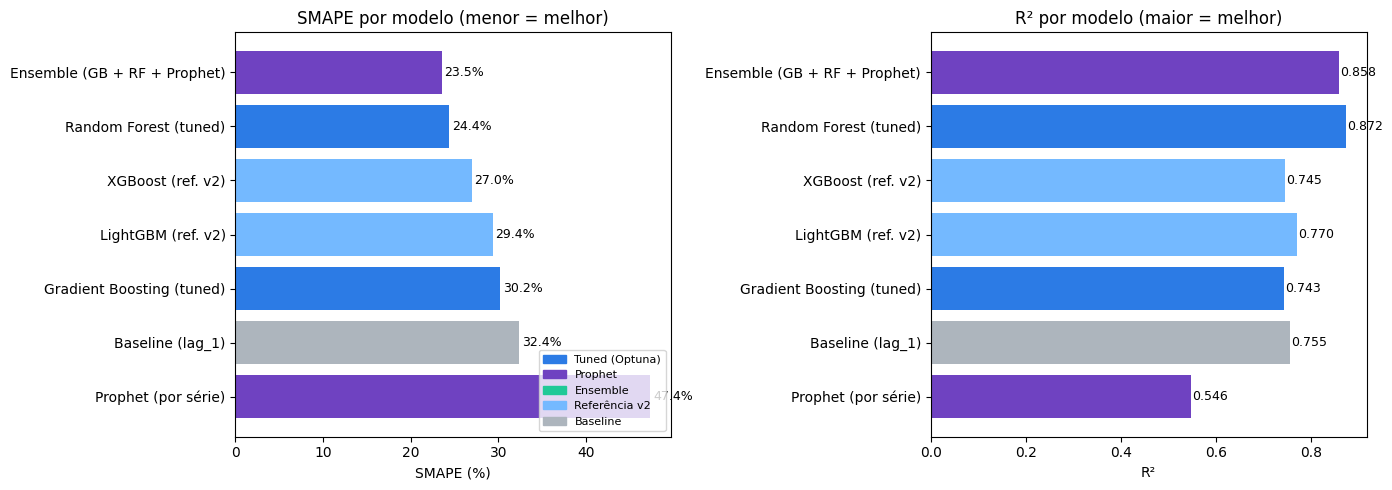

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def cor(nome):
    if 'Baseline' in nome:   return '#adb5bd'
    if 'tuned' in nome:      return '#2c7be5'
    if 'Prophet' in nome:    return '#6f42c1'
    if 'Ensemble' in nome:   return '#20c997'
    return '#74b9ff'

cores = [cor(m) for m in df_res['Modelo']]

axes[0].barh(df_res['Modelo'], df_res['SMAPE'], color=cores)
axes[0].set_xlabel('SMAPE (%)')
axes[0].set_title('SMAPE por modelo (menor = melhor)')
axes[0].invert_yaxis()
for i, v in enumerate(df_res['SMAPE']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

axes[1].barh(df_res['Modelo'], df_res['R2'], color=cores)
axes[1].set_xlabel('R²')
axes[1].set_title('R² por modelo (maior = melhor)')
axes[1].invert_yaxis()
for i, v in enumerate(df_res['R2']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# Legenda de cores
from matplotlib.patches import Patch
legend = [
    Patch(color='#2c7be5', label='Tuned (Optuna)'),
    Patch(color='#6f42c1', label='Prophet'),
    Patch(color='#20c997', label='Ensemble'),
    Patch(color='#74b9ff', label='Referência v2'),
    Patch(color='#adb5bd', label='Baseline'),
]
axes[0].legend(handles=legend, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

---
## 12. Feature Importance — Best ML Model

Feature importance scores from the best ML model (Gradient Boosting or Random Forest) reveal which inputs drive the predictions most. Lag features and rolling averages typically dominate, confirming that recent sales history is the strongest predictor of near-term volume.

Melhor modelo ML: Random Forest (tuned)


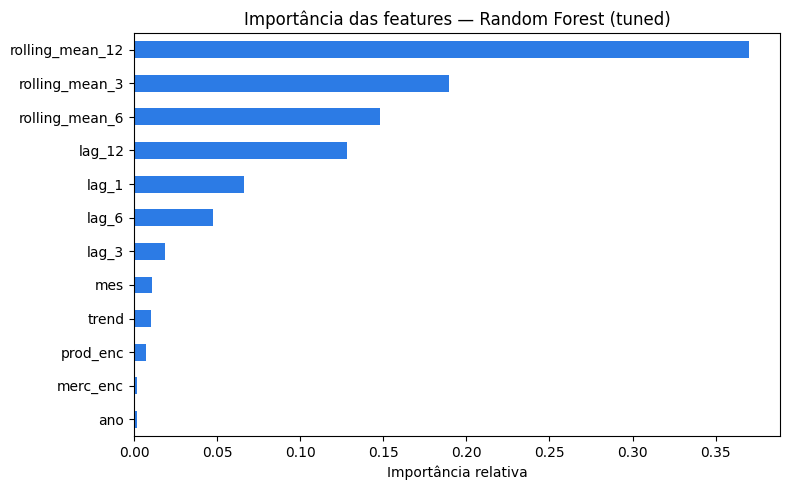

In [30]:
melhor_ml = df_res[~df_res['Modelo'].str.contains('Prophet|Ensemble|Baseline')].iloc[0]['Modelo']
print(f"Melhor modelo ML: {melhor_ml}")

modelo_ref = model_gb_tuned if 'Gradient' in melhor_ml else model_rf_tuned

importancias = pd.Series(modelo_ref.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='#2c7be5')
plt.title(f'Importância das features — {melhor_ml}')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

---
## 13. Per-Series Error Analysis

Aggregate metrics can mask poor performance on specific series. This section decomposes prediction errors by product-market pair, showing SMAPE and MAE individually for each series.

The top-4 series by volume are plotted with actual vs. predicted values over the 2024 test period, providing an intuitive quality check.

In [31]:
# Usar o melhor modelo individual (não ensemble) para análise por série
melhor_nome = df_res.iloc[0]['Modelo']

if 'Ensemble' in melhor_nome:
    y_final = y_pred_ensemble
    label_final = 'Ensemble'
elif 'Prophet' in melhor_nome:
    y_final = df_prophet_aligned
    label_final = 'Prophet'
elif 'Gradient' in melhor_nome:
    y_final = y_pred_gb_tuned
    label_final = 'GB tuned'
else:
    y_final = y_pred_rf_tuned
    label_final = 'RF tuned'

df_erros = df_test[['Prod_anom', 'Merc_anom', 'Data', 'Unidades']].copy().reset_index(drop=True)
df_erros['Previsto'] = y_final
df_erros['SMAPE_obs'] = (
    2 * np.abs(df_erros['Unidades'] - df_erros['Previsto']) /
    (df_erros['Unidades'].abs() + df_erros['Previsto'].abs() + 1e-9)
) * 100

smape_serie = (
    df_erros
    .groupby(['Prod_anom', 'Merc_anom'])
    .agg(SMAPE_medio=('SMAPE_obs', 'mean'), MAE_medio=('Unidades', lambda x: mean_absolute_error(x, df_erros.loc[x.index, 'Previsto'])))
    .sort_values('SMAPE_medio', ascending=False)
    .reset_index()
)

print(f"Erros por série — {label_final}:")
smape_serie.sort_values('Prod_anom').style.format({
    'SMAPE_medio': '{:.1f}%',
    'MAE_medio': '{:,.0f}'
})

Erros por série — Ensemble:


,Prod_anom,Merc_anom,SMAPE_medio,MAE_medio
5,M1_P1,M1,24.3%,"12,362"
9,M1_P2,M1,13.3%,"17,073"
10,M1_P3,M1,12.2%,"3,774"
7,M1_P4,M1,17.2%,"8,469"
2,M2_P1,M2,29.5%,"1,545"
1,M2_P2,M2,29.8%,"1,898"
11,M2_P3,M2,9.1%,"4,371"
8,M2_P4,M2,13.5%,"4,235"
3,M3_P1,M3,25.9%,"6,416"
6,M3_P2,M3,23.4%,"11,918"


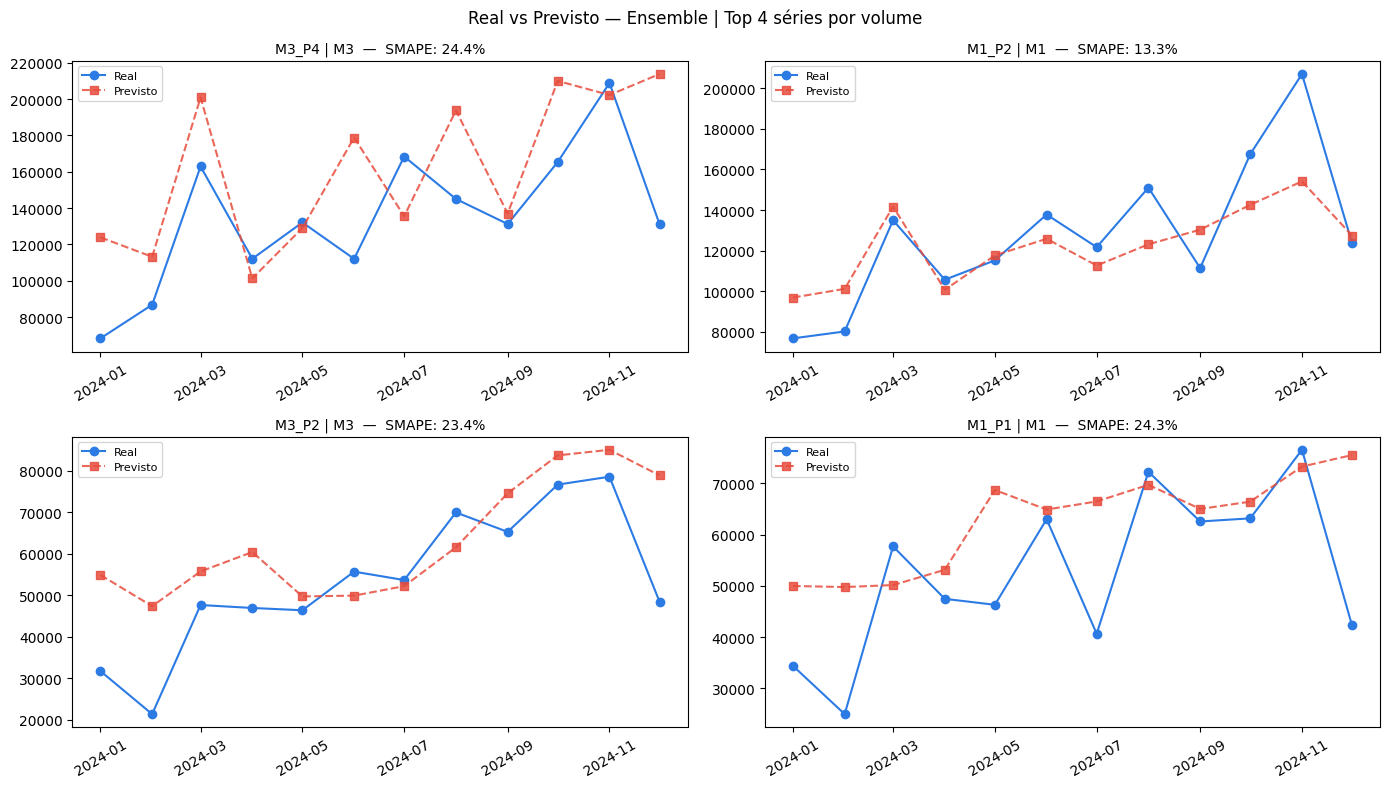

In [32]:
# Gráfico real vs previsto — top 4 séries por volume
top_series = (
    df_erros.groupby(['Prod_anom', 'Merc_anom'])['Unidades']
    .sum().nlargest(4).index
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (prod, merc) in zip(axes, top_series):
    sub = df_erros[(df_erros['Prod_anom'] == prod) & (df_erros['Merc_anom'] == merc)]
    smape_s = smape_serie.loc[
        (smape_serie['Prod_anom'] == prod) & (smape_serie['Merc_anom'] == merc),
        'SMAPE_medio'
    ].values[0]
    ax.plot(sub['Data'], sub['Unidades'], 'o-', label='Real',    color='#2c7be5')
    ax.plot(sub['Data'], sub['Previsto'], 's--', label='Previsto', color='#e74c3c', alpha=0.85)
    ax.set_title(f'{prod} | {merc}  —  SMAPE: {smape_s:.1f}%', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Real vs Previsto — {label_final} | Top 4 séries por volume', fontsize=12)
plt.tight_layout()
plt.show()

---
## 14. Multi-Step Projection — January to December 2025

The ensemble is used to generate a 12-month forward forecast using an **iterative (recursive) multi-step strategy**:

1. For each month in the projection horizon, lag features and rolling averages are recomputed using the combination of real historical data and previously generated forecasts.
2. Gradient Boosting and Random Forest each produce a prediction; Prophet projects independently using the full historical series as input.
3. The three predictions are combined with the optimized ensemble weights from Section 10.

This approach avoids data leakage and accurately replicates how the model would be used in a production setting, where future actuals are never available at inference time.

In [33]:
# ── Configurações da projeção ─────────────────────────────────────────────────
meses_futuros = pd.date_range(start='2025-01-01', periods=12, freq='MS')
series_proj   = df_model[['Prod_anom', 'Merc_anom']].drop_duplicates().values.tolist()

# Base histórica completa (treino + teste) — serve de âncora para os lags
# Usamos df_model completo (até dez/2024) como histórico real
historico = df_model[['Prod_anom', 'Merc_anom', 'Data', 'Unidades']].copy()

# Encodings calculados no treino (já existem como colunas em df_model)
enc_lookup = df_model[['Prod_anom', 'Merc_anom', 'prod_enc', 'merc_enc']].drop_duplicates()

# Número de observações por série até dez/2024 (para calcular trend futuro)
trend_base = (
    df_model.groupby(['Prod_anom', 'Merc_anom'])['trend'].max().reset_index()
    .rename(columns={'trend': 'trend_max'})
)

print(f"Séries a projetar: {len(series_proj)}")
print(f"Período: {meses_futuros[0].date()} → {meses_futuros[-1].date()}")
print(f"Histórico disponível: {historico['Data'].min().date()} → {historico['Data'].max().date()}")

Séries a projetar: 12
Período: 2025-01-01 → 2025-12-01
Histórico disponível: 2021-01-01 → 2024-12-01


In [34]:
# ── Projeção ML multi-step (GB + RF) ─────────────────────────────────────────
# Para cada série e cada mês futuro:
#   1. Calcula lags e médias móveis usando histórico real + previsões anteriores
#   2. Monta o vetor de features
#   3. Gera previsão GB e RF separadamente (para combinar no ensemble depois)

from io import StringIO
import sys

proj_ml_records = []

for prod, merc in series_proj:

    # Histórico desta série (real até dez/2024)
    hist_serie = (
        historico[(historico['Prod_anom'] == prod) & (historico['Merc_anom'] == merc)]
        .sort_values('Data')[['Data', 'Unidades']]
        .copy()
    )

    # Encodings
    row_enc = enc_lookup[(enc_lookup['Prod_anom'] == prod) & (enc_lookup['Merc_anom'] == merc)].iloc[0]
    prod_enc_val = row_enc['prod_enc']
    merc_enc_val = row_enc['merc_enc']

    # Trend base (último valor observado)
    trend_val = trend_base[(trend_base['Prod_anom'] == prod) & (trend_base['Merc_anom'] == merc)]['trend_max'].values[0]

    # Série estendida com previsões (começa com histórico real)
    serie_ext = hist_serie.set_index('Data')['Unidades'].copy()

    pred_gb_list = []
    pred_rf_list = []

    for i, mes in enumerate(meses_futuros):
        trend_val += 1

        # Lags — buscam valores na série estendida (real + previsões anteriores)
        def get_lag(n):
            data_alvo = mes - pd.DateOffset(months=n)
            return serie_ext.get(data_alvo, np.nan)

        lag_1  = get_lag(1)
        lag_3  = get_lag(3)
        lag_6  = get_lag(6)
        lag_12 = get_lag(12)

        # Médias móveis (usando valores disponíveis na série estendida)
        def rolling_mean(w):
            vals = [serie_ext.get(mes - pd.DateOffset(months=k), np.nan) for k in range(1, w+1)]
            vals = [v for v in vals if not np.isnan(v)]
            return np.mean(vals) if vals else np.nan

        rm_3  = rolling_mean(3)
        rm_6  = rolling_mean(6)
        rm_12 = rolling_mean(12)

        feat = pd.DataFrame([{
            'lag_1': lag_1, 'lag_3': lag_3, 'lag_6': lag_6, 'lag_12': lag_12,
            'rolling_mean_3': rm_3, 'rolling_mean_6': rm_6, 'rolling_mean_12': rm_12,
            'mes': mes.month, 'ano': mes.year, 'trend': trend_val,
            'prod_enc': prod_enc_val, 'merc_enc': merc_enc_val
        }])[features]

        # Prever com GB e RF
        p_gb = float(model_gb_tuned.predict(feat)[0])
        p_rf = float(model_rf_tuned.predict(feat)[0])

        pred_gb_list.append(max(p_gb, 0))
        pred_rf_list.append(max(p_rf, 0))

        # Atualizar série com média GB+RF ponderada (sem Prophet aqui — Prophet projeta separado)
        # Usamos a previsão ponderada provisória como âncora para lags futuros
        p_ml_provisorio = pesos_opt[0] * max(p_gb, 0) + pesos_opt[1] * max(p_rf, 0)
        serie_ext[mes] = p_ml_provisorio

    for i, mes in enumerate(meses_futuros):
        proj_ml_records.append({
            'Prod_anom': prod, 'Merc_anom': merc, 'Data': mes,
            'pred_gb': pred_gb_list[i], 'pred_rf': pred_rf_list[i]
        })

df_proj_ml = pd.DataFrame(proj_ml_records)
print(f"Projeção ML gerada: {df_proj_ml.shape[0]} linhas")
df_proj_ml.head()

Projeção ML gerada: 144 linhas


,Prod_anom,Merc_anom,Data,pred_gb,pred_rf
0,M1_P1,M1,2025-01-01,43514.080214,51769.175635
1,M1_P1,M1,2025-02-01,51585.778469,51545.922337
2,M1_P1,M1,2025-03-01,60918.234411,53818.446951
3,M1_P1,M1,2025-04-01,60291.614542,56353.437338
4,M1_P1,M1,2025-05-01,82562.587356,60734.531609


In [35]:
# ── Projeção Prophet por série ────────────────────────────────────────────────
# Prophet projeta diretamente 12 meses à frente a partir do histórico completo

from prophet import Prophet

prophet_proj_records = []

for prod, merc in series_proj:
    serie = (
        historico[(historico['Prod_anom'] == prod) & (historico['Merc_anom'] == merc)]
        .sort_values('Data')[['Data', 'Unidades']]
        .rename(columns={'Data': 'ds', 'Unidades': 'y'})
        .copy()
    )

    if len(serie) < 12:
        for mes in meses_futuros:
            prophet_proj_records.append({'Prod_anom': prod, 'Merc_anom': merc, 'Data': mes, 'pred_prophet': 0})
        continue

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.95,
        changepoint_prior_scale=0.05
    )

    old_stdout = sys.stdout
    sys.stdout = StringIO()
    m.fit(serie)
    sys.stdout = old_stdout

    future   = m.make_future_dataframe(periods=12, freq='MS')
    forecast = m.predict(future)
    proj_p   = forecast[forecast['ds'].isin(meses_futuros)][['ds', 'yhat']].copy()
    proj_p['yhat'] = proj_p['yhat'].clip(lower=0)

    for _, row in proj_p.iterrows():
        prophet_proj_records.append({
            'Prod_anom': prod, 'Merc_anom': merc,
            'Data': row['ds'], 'pred_prophet': row['yhat']
        })

df_proj_prophet = pd.DataFrame(prophet_proj_records)
print(f"Projeção Prophet gerada: {df_proj_prophet.shape[0]} linhas")
df_proj_prophet.head()

Projeção Prophet gerada: 144 linhas


,Prod_anom,Merc_anom,Data,pred_prophet
0,M1_P1,M1,2025-01-01,40061.394656
1,M1_P1,M1,2025-02-01,40727.040147
2,M1_P1,M1,2025-03-01,56673.835852
3,M1_P1,M1,2025-04-01,48397.550908
4,M1_P1,M1,2025-05-01,60280.615503


In [36]:
# ── Combinar ML + Prophet com pesos otimizados do ensemble ────────────────────
df_proj = df_proj_ml.merge(df_proj_prophet, on=['Prod_anom', 'Merc_anom', 'Data'], how='left')

df_proj['Projecao_Unidades'] = (
    pesos_opt[0] * df_proj['pred_gb'] +
    pesos_opt[1] * df_proj['pred_rf'] +
    pesos_opt[2] * df_proj['pred_prophet']
).clip(lower=0).round(1)

print("Pesos aplicados:")
print(f"  GB tuned:  {pesos_opt[0]:.3f}")
print(f"  RF tuned:  {pesos_opt[1]:.3f}")
print(f"  Prophet:   {pesos_opt[2]:.3f}")
print()
print("Prévia das projeções por série:")
df_proj[['Prod_anom', 'Merc_anom', 'Data', 'Projecao_Unidades']].head(12)

Pesos aplicados:
  GB tuned:  0.286
  RF tuned:  0.579
  Prophet:   0.134

Prévia das projeções por série:


,Prod_anom,Merc_anom,Data,Projecao_Unidades
0,M1_P1,M1,2025-01-01,47833.8
1,M1_P1,M1,2025-02-01,50106.0
2,M1_P1,M1,2025-03-01,56235.3
3,M1_P1,M1,2025-04-01,56414.3
4,M1_P1,M1,2025-05-01,66926.4
5,M1_P1,M1,2025-06-01,65372.8
6,M1_P1,M1,2025-07-01,60895.8
7,M1_P1,M1,2025-08-01,62248.7
8,M1_P1,M1,2025-09-01,62821.3
9,M1_P1,M1,2025-10-01,63564.5


---
## 15. Aggregation by Product and Excel Export

Individual product-market projections are summed to the product level, producing a concise pivot table (products × months) for reporting purposes.

The output Excel workbook contains three sheets:
1. **Projeção por Produto** — pivot table with monthly totals and an annual total column
2. **Detalhe Produto-Mercado** — granular view with one row per series per month
3. **Métricas do Modelo** — full model comparison table from Section 11

A final set of charts overlays the last 24 months of historical data with the 2025 projections for each product.

In [37]:
# ── Agregar por Prod_anom ─────────────────────────────────────────────────────
df_proj_prod = (
    df_proj
    .groupby(['Prod_anom', 'Data'], as_index=False)
    .agg(Projecao_Unidades=('Projecao_Unidades', 'sum'))
)

df_proj_prod['Ano']  = df_proj_prod['Data'].dt.year
df_proj_prod['Mes']  = df_proj_prod['Data'].dt.month
df_proj_prod['Data_str'] = df_proj_prod['Data'].dt.strftime('%Y-%m')

print("Projeções por produto (Jan–Dez 2025):")
df_proj_prod[['Prod_anom', 'Data_str', 'Projecao_Unidades']]

Projeções por produto (Jan–Dez 2025):


,Prod_anom,Data_str,Projecao_Unidades
0,M1_P1,2025-01,47833.8
1,M1_P1,2025-02,50106.0
2,M1_P1,2025-03,56235.3
3,M1_P1,2025-04,56414.3
4,M1_P1,2025-05,66926.4
5,M1_P1,2025-06,65372.8
6,M1_P1,2025-07,60895.8
7,M1_P1,2025-08,62248.7
8,M1_P1,2025-09,62821.3
9,M1_P1,2025-10,63564.5


In [38]:
# ── Tabela pivô — Produto x Mês ───────────────────────────────────────────────
pivot_proj = df_proj_prod.pivot_table(
    index='Prod_anom',
    columns='Data_str',
    values='Projecao_Unidades',
    aggfunc='sum'
).round(0).astype(int)

pivot_proj.columns.name = None
pivot_proj.index.name = 'Produto'

# Adicionar total anual
pivot_proj['Total 2025'] = pivot_proj.sum(axis=1)

print("Tabela de projeção — Jan a Dez 2025:")
pivot_proj

Tabela de projeção — Jan a Dez 2025:


,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,Total 2025
Produto,,,,,,,,,,,,,
M1_P1,47834,50106,56235,56414,66926,65373,60896,62249,62821,63564,67200,60224,719842
M1_P2,113552,110329,144864,106683,126779,167579,131522,187864,148536,196849,218412,142199,1795168
M1_P3,29947,30564,34108,36939,39326,39485,39487,38506,38590,48374,48084,38926,462336
M1_P4,60384,54578,64974,66779,67104,64698,61263,66868,65934,64778,54469,53258,745087
M2_P1,4074,4717,4771,4588,6385,6671,6502,7114,6675,6980,7522,4621,70620
M2_P2,3551,3368,3887,4864,5754,5492,5593,5798,5719,4698,5392,3558,57674
M2_P3,47815,45818,55984,53313,64037,63492,50286,60316,63621,64523,63200,60246,692651
M2_P4,32314,33439,47273,37992,45643,48378,43485,43546,49402,43164,49518,35614,509768
M3_P1,24249,21302,23146,25002,25596,30014,27324,27300,26400,29569,26438,27989,314329


In [39]:
# ── Exportar para Excel ───────────────────────────────────────────────────────
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

output_path = '/content/drive/MyDrive/0. Dev/1. Modelo de Projeção/Projeções Geradas no modelo/Projecoes_2025.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # ── Aba 1: Tabela pivô (Produto x Mês) ───────────────────────────────────
    pivot_proj.to_excel(writer, sheet_name='Projeção por Produto', startrow=2)

    ws1 = writer.sheets['Projeção por Produto']

    # Título
    ws1['A1'] = 'Projeções de Unidades — Jan a Dez 2025'
    ws1['A1'].font = Font(bold=True, size=13)
    ws1['A2'] = f'Modelo: Ensemble (GB tuned {pesos_opt[0]:.0%} + RF tuned {pesos_opt[1]:.0%} + Prophet {pesos_opt[2]:.0%})'
    ws1['A2'].font = Font(italic=True, size=10, color='666666')

    # Estilo cabeçalho
    header_fill = PatternFill(fill_type='solid', fgColor='1F3864')
    header_font = Font(bold=True, color='FFFFFF', size=10)
    for cell in ws1[3]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')

    # Estilo coluna Total
    total_fill = PatternFill(fill_type='solid', fgColor='D9E1F2')
    total_font = Font(bold=True, size=10)
    total_col = pivot_proj.shape[1] + 1   # +1 pelo index
    for row in ws1.iter_rows(min_row=4, max_row=3+len(pivot_proj), min_col=total_col+1, max_col=total_col+1):
        for cell in row:
            cell.fill = total_fill
            cell.font = total_font

    # Zebrar linhas de dados
    zebra_fill = PatternFill(fill_type='solid', fgColor='EEF2FF')
    for i, row in enumerate(ws1.iter_rows(min_row=4, max_row=3+len(pivot_proj))):
        if i % 2 == 1:
            for cell in row:
                if cell.fill.fgColor.rgb == '00000000':
                    cell.fill = zebra_fill

    # Largura das colunas
    ws1.column_dimensions['A'].width = 16
    for col in range(2, pivot_proj.shape[1] + 3):
        ws1.column_dimensions[get_column_letter(col)].width = 13

    # ── Aba 2: Detalhe por Série (Produto + Mercado) ──────────────────────────
    df_detalhe = df_proj[['Prod_anom', 'Merc_anom', 'Data', 'Projecao_Unidades']].copy()
    df_detalhe['Data'] = df_detalhe['Data'].dt.strftime('%Y-%m')
    df_detalhe = df_detalhe.rename(columns={
        'Prod_anom': 'Produto', 'Merc_anom': 'Mercado',
        'Data': 'Mês', 'Projecao_Unidades': 'Unidades Projetadas'
    }).sort_values(['Produto', 'Mercado', 'Mês'])

    df_detalhe.to_excel(writer, sheet_name='Detalhe Produto-Mercado', index=False, startrow=1)

    ws2 = writer.sheets['Detalhe Produto-Mercado']
    ws2['A1'] = 'Detalhe por Produto e Mercado — Jan a Dez 2025'
    ws2['A1'].font = Font(bold=True, size=12)

    for cell in ws2[2]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')

    for col_letter, width in [('A', 16), ('B', 16), ('C', 12), ('D', 20)]:
        ws2.column_dimensions[col_letter].width = width

    # ── Aba 3: Métricas do modelo ─────────────────────────────────────────────
    df_res.to_excel(writer, sheet_name='Métricas do Modelo', index=False, startrow=2)

    ws3 = writer.sheets['Métricas do Modelo']
    ws3['A1'] = 'Métricas de avaliação — Base de teste Jan a Dez 2024'
    ws3['A1'].font = Font(bold=True, size=12)

    for cell in ws3[3]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')

    for col_letter, width in [('A', 30), ('B', 12), ('C', 12), ('D', 14), ('E', 14), ('F', 10)]:
        ws3.column_dimensions[col_letter].width = width

print(f"\nArquivo salvo em:")
print(f"  {output_path}")
print(f"\nAbas geradas:")
print(f"  1. Projeção por Produto  — tabela pivô produto x mês")
print(f"  2. Detalhe Produto-Mercado — linha por série e mês")
print(f"  3. Métricas do Modelo    — resultados da avaliação no teste 2024")


Arquivo salvo em:
  /content/drive/MyDrive/0. Dev/1. Modelo de Projeção/Projeções Geradas no modelo/Projecoes_2025.xlsx

Abas geradas:
  1. Projeção por Produto  — tabela pivô produto x mês
  2. Detalhe Produto-Mercado — linha por série e mês
  3. Métricas do Modelo    — resultados da avaliação no teste 2024


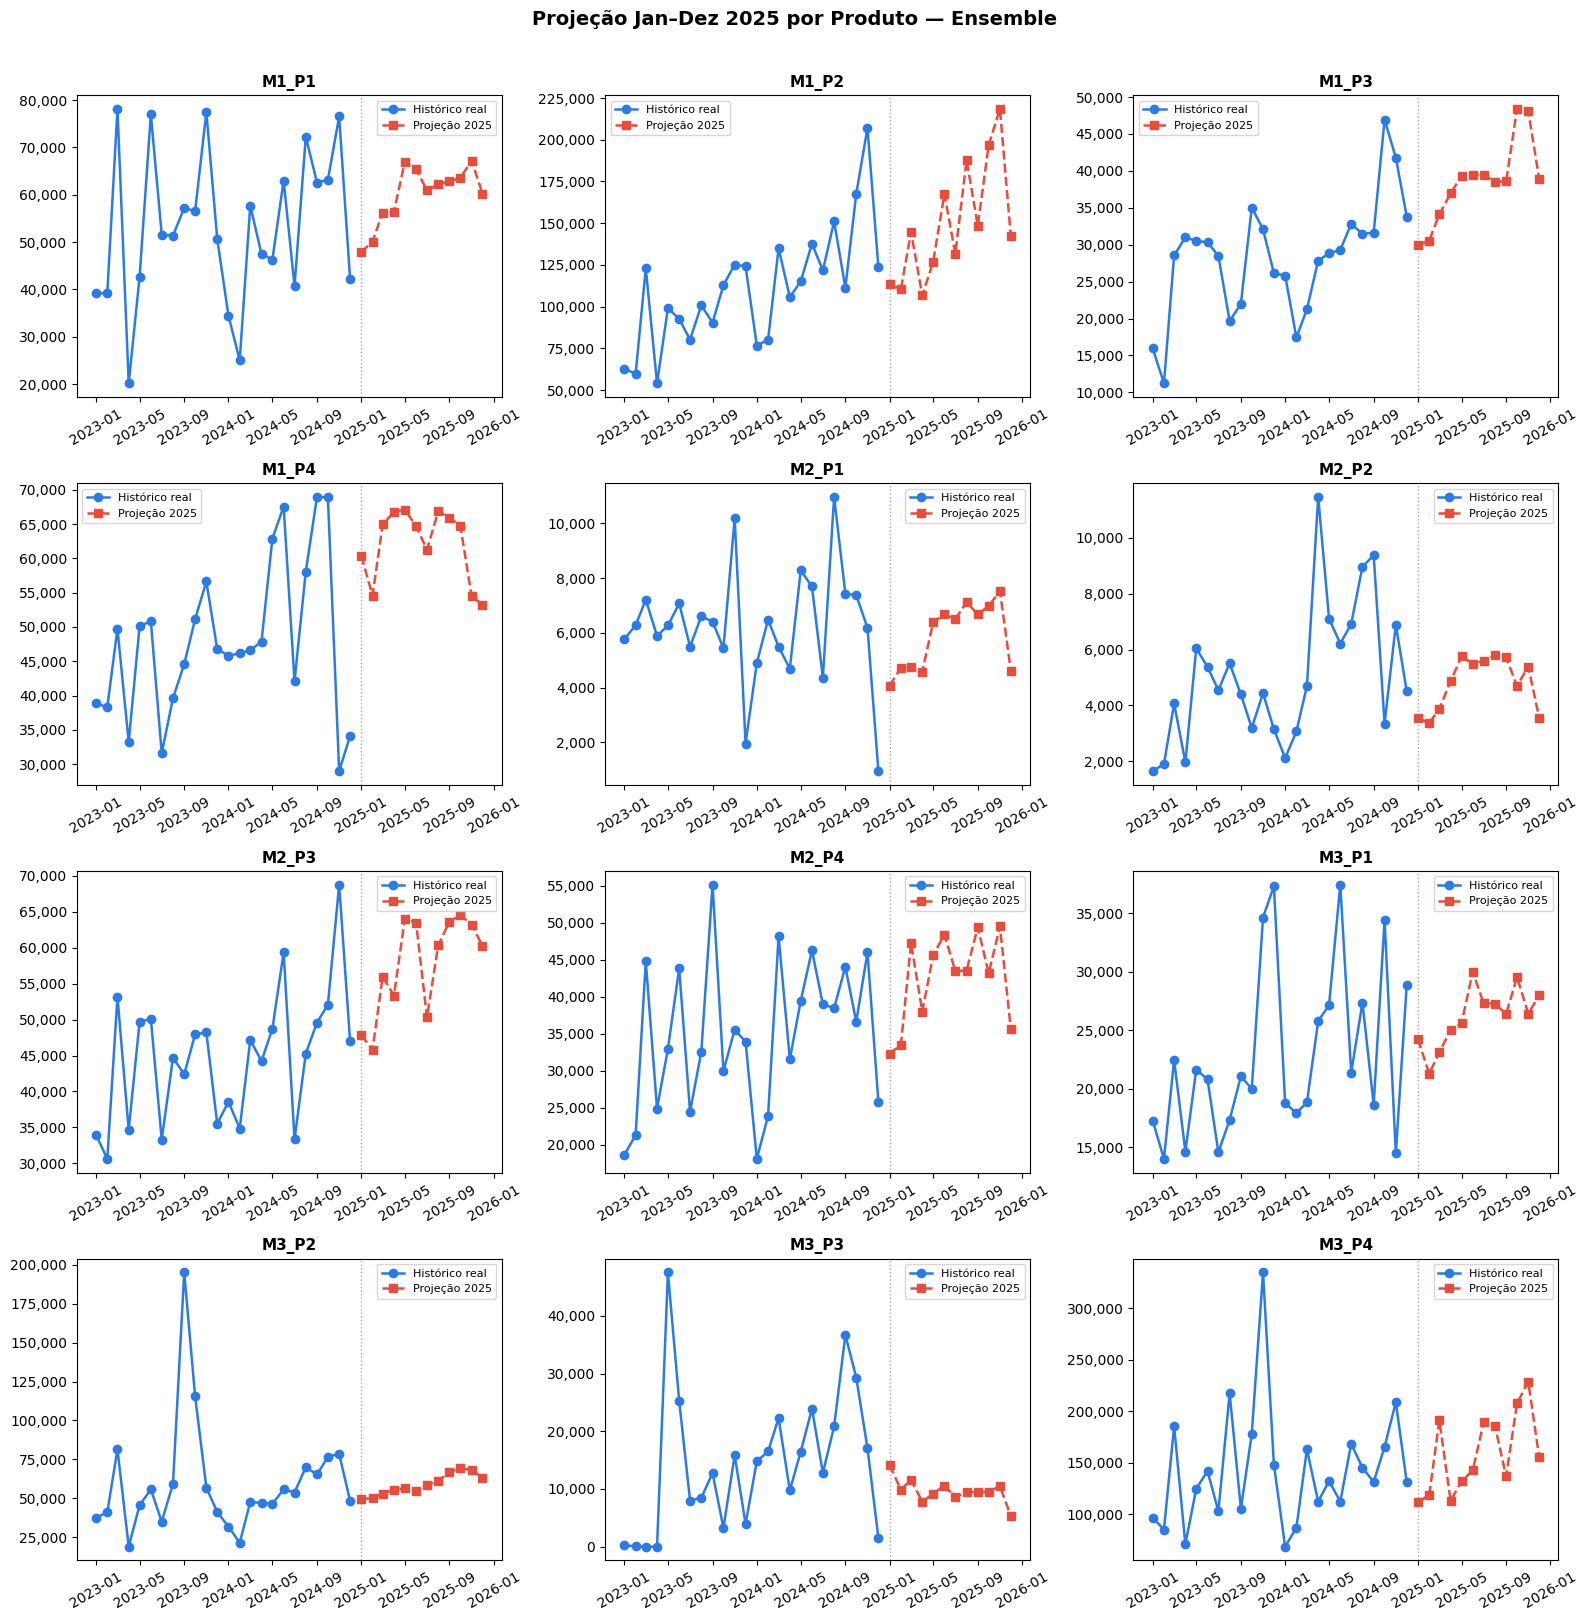

In [40]:
# ── Gráfico das projeções por produto ─────────────────────────────────────────
produtos = sorted(df_proj_prod['Prod_anom'].unique())
n = len(produtos)
ncols = 3
nrows = -(-n // ncols)   # teto da divisão

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, prod in enumerate(produtos):
    ax = axes[i]

    # Histórico real (últimos 24 meses)
    hist = (
        historico[historico['Prod_anom'] == prod]
        .groupby('Data')['Unidades'].sum()
        .sort_index()
        .tail(24)
    )

    # Projeção 2025
    proj = df_proj_prod[df_proj_prod['Prod_anom'] == prod].set_index('Data')['Projecao_Unidades']

    ax.plot(hist.index, hist.values, 'o-', color='#2c7be5', linewidth=1.8, label='Histórico real')
    ax.plot(proj.index, proj.values, 's--', color='#e74c3c', linewidth=1.8, label='Projeção 2025')

    # Linha separando histórico de projeção
    ax.axvline(x=pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=1, alpha=0.7)

    ax.set_title(prod, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Ocultar eixos extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Projeção Jan–Dez 2025 por Produto — Ensemble', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()